# Task 1: Credit Scoring Visualizations
This notebook generates professional plots to demonstrate the relationships between financial features and creditworthiness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Data Generation
def generate_credit_data(n_samples=2000):
    np.random.seed(42)
    income = np.random.normal(50000, 15000, n_samples)
    age = np.random.randint(18, 70, n_samples)
    employment_years = np.random.randint(0, 40, n_samples)
    debt = np.random.normal(10000, 5000, n_samples)
    payment_history = np.random.uniform(0, 1, n_samples)
    score = (0.3 * (income / 50000) + 0.4 * payment_history + 0.2 * (employment_years / 20) - 0.3 * (debt / 10000))
    target = ((score + np.random.normal(0, 0.1, n_samples)) > 0.5).astype(int)
    return pd.DataFrame({'income': income, 'age': age, 'employment_years': employment_years, 'debt': debt, 'payment_history': payment_history, 'creditworthy': target})

df = generate_credit_data()
X = df.drop('creditworthy', axis=1)
y = df['creditworthy']
X['debt_to_income'] = X['debt'] / X['income']

print("Dataset ready for visualization.")

Dataset ready for visualization.


## Visualization 1: Feature Correlation Heatmap
Shows how strongly each feature is related to others and the target variable.

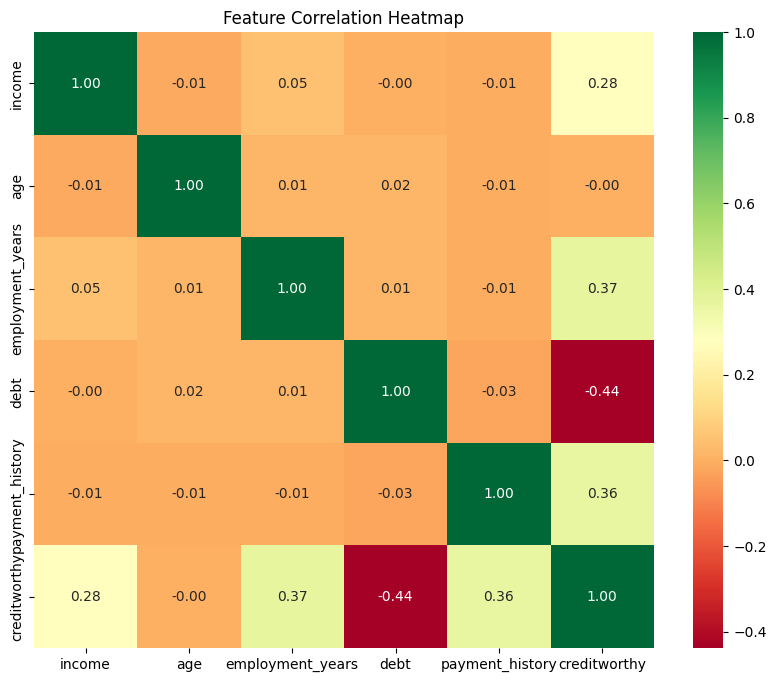

In [2]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

## Visualization 2: Income vs Debt Distribution
Analyzes the relationship between income and debt, colored by creditworthiness.

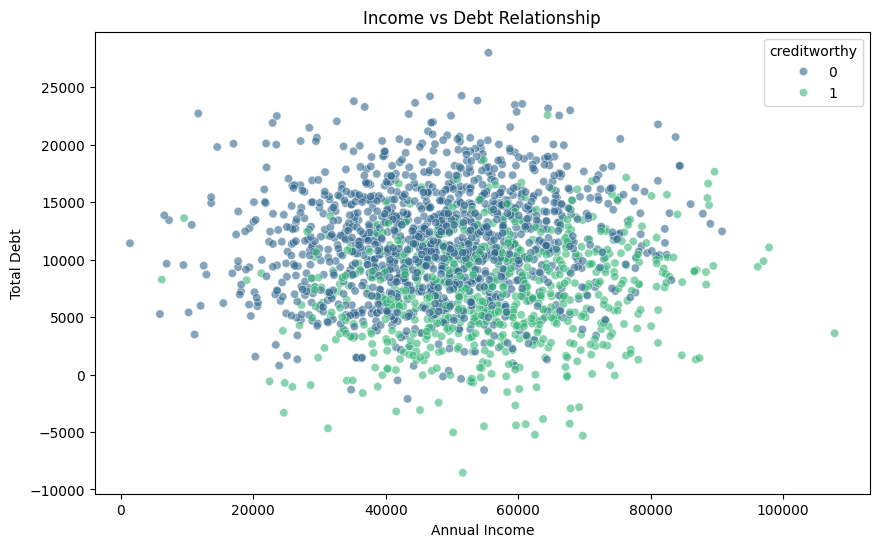

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='debt', hue='creditworthy', alpha=0.6, palette='viridis')
plt.title("Income vs Debt Relationship")
plt.xlabel("Annual Income")
plt.ylabel("Total Debt")
plt.show()

## Visualization 3: Model Feature Importance
Displays which features the Random Forest model found most important for prediction.

C:\Users\HP\AppData\Local\Temp\ipykernel_16640\800760332.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette='magma')


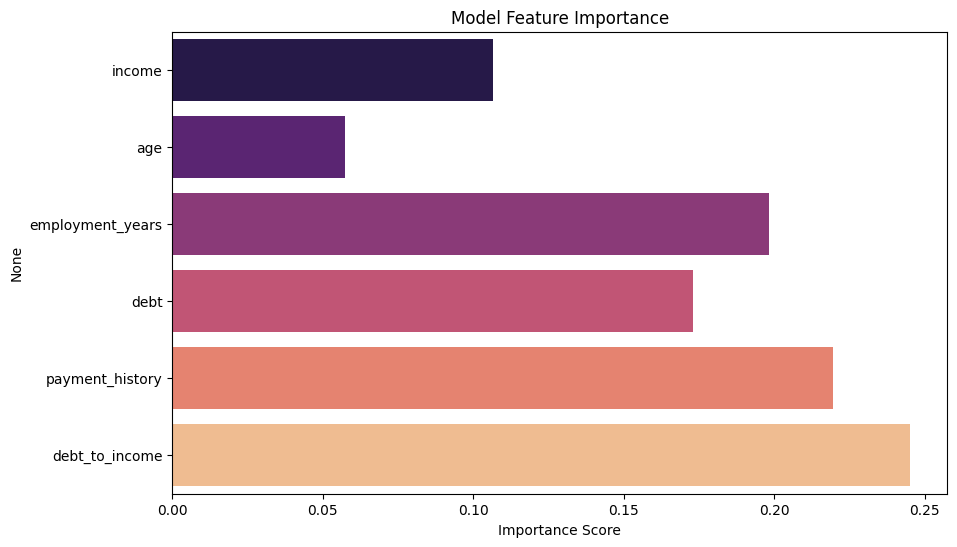

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
sns.barplot(x=model.feature_importances_, y=X.columns, palette='magma')
plt.title("Model Feature Importance")
plt.xlabel("Importance Score")
plt.show()